In [19]:
# ============================================================
# CELL 0 — COMPLETE SETUP (Run this first every session)
# After this cell, run: 3B → 3C → 3D → verification cells
# You do NOT need to run 3A separately — config is here.
# ============================================================

# ── Imports ───────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# ── Device ────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── DataLoader Config (from Step 2) ──────────────────────────
BATCH_SIZE  = 64
MAX_SRC_LEN = 81
MAX_TGT_LEN = 12

# ── Encoder Config (from Step 3A) ────────────────────────────
EMBEDDING_DIM = 128
HIDDEN_DIM    = 256
NUM_LAYERS    = 2
DROPOUT       = 0.5
BIDIRECTIONAL = True

# ── Vocabulary Class ──────────────────────────────────────────
class Vocabulary:
    PAD_TOKEN = "<PAD>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"
    UNK_TOKEN = "<UNK>"
    PAD_IDX = 0
    SOS_IDX = 1
    EOS_IDX = 2
    UNK_IDX = 3

    def __init__(self, min_freq=2):
        self.min_freq  = min_freq
        self.word2idx  = {}
        self.idx2word  = {}
        self.word_freq = Counter()
        self.vocab_size = 0

    @staticmethod
    def tokenize(text):
        if not isinstance(text, str):
            return []
        return text.lower().strip().split()

    def fit(self, sentences):
        for sentence in sentences:
            self.word_freq.update(self.tokenize(sentence))
        return self

    def build(self):
        self.word2idx = {
            self.PAD_TOKEN: self.PAD_IDX,
            self.SOS_TOKEN: self.SOS_IDX,
            self.EOS_TOKEN: self.EOS_IDX,
            self.UNK_TOKEN: self.UNK_IDX,
        }
        for word, freq in self.word_freq.most_common():
            if freq >= self.min_freq and word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)
        self.idx2word   = {idx: word for word, idx in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)
        return self

    def encode(self, sentence, add_sos=False, add_eos=True):
        tokens  = self.tokenize(sentence)
        indices = [self.word2idx.get(t, self.UNK_IDX) for t in tokens]
        if add_sos: indices = [self.SOS_IDX] + indices
        if add_eos: indices = indices + [self.EOS_IDX]
        return indices

    def decode(self, indices, skip_special=True):
        special = {self.PAD_IDX, self.SOS_IDX, self.EOS_IDX}
        words = []
        for idx in indices:
            if skip_special and idx in special:
                continue
            word = self.idx2word.get(idx, self.UNK_TOKEN)
            words.append(word)
            if word == self.EOS_TOKEN and not skip_special:
                break
        return " ".join(words)

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(self, f)

    @classmethod
    def load(cls, path):
        with open(path, "rb") as f:
            vocab = pickle.load(f)
        print(f"Vocabulary loaded ← {path} ({vocab.vocab_size:,} words)")
        return vocab

# ── Dataset Class ─────────────────────────────────────────────
class ReviewSummarizationDataset(Dataset):
    def __init__(self, df, vocab, max_src_len, max_tgt_len):
        self.vocab       = vocab
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
        df = df.dropna(subset=["body_final", "title_final"]).reset_index(drop=True)
        self.bodies = df["body_final"].tolist()
        self.titles = df["title_final"].tolist()

    def __len__(self):
        return len(self.bodies)

    def __getitem__(self, idx):
        src_ids = self.vocab.encode(str(self.bodies[idx]), add_sos=False, add_eos=True)
        src_len = min(len(src_ids), self.max_src_len)
        src_ids = src_ids[:self.max_src_len]
        src_ids = src_ids + [self.vocab.PAD_IDX] * (self.max_src_len - len(src_ids))

        tgt_ids = self.vocab.encode(str(self.titles[idx]), add_sos=True, add_eos=True)
        tgt_len = min(len(tgt_ids), self.max_tgt_len)
        tgt_ids = tgt_ids[:self.max_tgt_len]
        tgt_ids = tgt_ids + [self.vocab.PAD_IDX] * (self.max_tgt_len - len(tgt_ids))

        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long),
            torch.tensor(src_len, dtype=torch.long),
            torch.tensor(tgt_len, dtype=torch.long),
        )

# ── Collate Function ──────────────────────────────────────────
def collate_fn(batch):
    srcs, tgts, src_lens, tgt_lens = zip(*batch)
    srcs     = torch.stack(srcs)
    tgts     = torch.stack(tgts)
    src_lens = torch.stack(src_lens)
    tgt_lens = torch.stack(tgt_lens)
    src_lens, sort_idx = src_lens.sort(descending=True)
    srcs     = srcs[sort_idx]
    tgts     = tgts[sort_idx]
    tgt_lens = tgt_lens[sort_idx]
    return srcs, tgts, src_lens, tgt_lens

# ── Load Vocabulary ───────────────────────────────────────────
vocab = Vocabulary.load("vocabulary.pkl")

# ── Load CSVs ─────────────────────────────────────────────────
train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")

# ── Build DataLoaders ─────────────────────────────────────────
train_dataset = ReviewSummarizationDataset(train_df, vocab, MAX_SRC_LEN, MAX_TGT_LEN)
val_dataset   = ReviewSummarizationDataset(val_df,   vocab, MAX_SRC_LEN, MAX_TGT_LEN)
test_dataset  = ReviewSummarizationDataset(test_df,  vocab, MAX_SRC_LEN, MAX_TGT_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0,
                          pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0,
                          pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0,
                          pin_memory=torch.cuda.is_available())

# ── Confirm Everything ────────────────────────────────────────
print("=" * 55)
print("  CELL 0 COMPLETE — All dependencies ready")
print("=" * 55)
print(f"  Device         : {DEVICE}")
print(f"  Vocab size     : {vocab.vocab_size:,}")
print(f"  Train batches  : {len(train_loader):,}")
print(f"  Val batches    : {len(val_loader):,}")
print(f"  Test batches   : {len(test_loader):,}")
print(f"  EMBEDDING_DIM  : {EMBEDDING_DIM}")
print(f"  HIDDEN_DIM     : {HIDDEN_DIM}")
print(f"  NUM_LAYERS     : {NUM_LAYERS}")
print(f"  DROPOUT        : {DROPOUT}")
print(f"  BIDIRECTIONAL  : {BIDIRECTIONAL}")
print("=" * 55)
print("  Next → run Cell 3B, then 3C, then 3D")
print("=" * 55)

Vocabulary loaded ← vocabulary.pkl (33,379 words)
  CELL 0 COMPLETE — All dependencies ready
  Device         : cpu
  Vocab size     : 33,379
  Train batches  : 451
  Val batches    : 51
  Test batches   : 56
  EMBEDDING_DIM  : 128
  HIDDEN_DIM     : 256
  NUM_LAYERS     : 2
  DROPOUT        : 0.5
  BIDIRECTIONAL  : True
  Next → run Cell 3B, then 3C, then 3D


In [20]:
import pickle
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from collections import Counter

EMBEDDING_DIM = 128   # Size of each word's vector representation.
                      # Every word in the vocabulary gets a vector
                      # of this many numbers. Larger = more expressive
                      # but slower to train.

HIDDEN_DIM    = 256   # Size of the RNN's memory at each step.
                      # This is how much the encoder "remembers"
                      # as it reads through the review word by word.
                      # Must be EVEN if using bidirectional (we are).

NUM_LAYERS    = 2     # Number of stacked GRU layers.
                      # Layer 1 reads raw embeddings.
                      # Layer 2 reads layer 1's output — learns
                      # higher-level patterns.

DROPOUT       = 0.5   # During training, randomly zero out 50% of
                      # neurons. Forces the network to not rely on
                      # any single neuron — improves generalization.
                      # Dropout is DISABLED during inference automatically.

BIDIRECTIONAL = True  # Read the review forwards AND backwards.
                      # The forward pass sees: "book good story great"
                      # The backward pass sees: "great story good book"
                      # Both perspectives are combined, giving the
                      # encoder richer context for each word.

class Vocabulary:
    """
    Builds a word-to-index mapping from a corpus.

    Special tokens:
        <PAD> = 0  → used to pad sequences to equal length in a batch
        <SOS> = 1  → Start Of Sequence, fed as first token to the decoder
        <EOS> = 2  → End Of Sequence, signals the decoder to stop generating
        <UNK> = 3  → Unknown token, replaces any word not in vocabulary
    """

    PAD_TOKEN = "<PAD>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"
    UNK_TOKEN = "<UNK>"

    PAD_IDX = 0
    SOS_IDX = 1
    EOS_IDX = 2
    UNK_IDX = 3

    def __init__(self, min_freq: int = 2):
        """
        Args:
            min_freq: words appearing fewer than this many times
                      across the whole corpus are mapped to <UNK>.
                      Keeps vocabulary size manageable.
        """
        self.min_freq = min_freq

        # These are set after calling .build()
        self.word2idx = {}
        self.idx2word = {}
        self.word_freq = Counter()
        self.vocab_size = 0

    # ── tokenizer ──────────────────────────────────────────
    @staticmethod
    def tokenize(text: str) -> list[str]:
        """
        Simple whitespace tokenizer.
        The data is already cleaned so no need for anything fancier.
        Returns a list of lowercase tokens.
        """
        if not isinstance(text, str):
            return []
        return text.lower().strip().split()

    # ── count word frequencies ─────────────────────────────
    def fit(self, sentences: list[str]):
        """
        Count every word in the corpus.
        Call this on BOTH source (body) and target (title) sentences
        so both sides share the same vocabulary.
        (Shared vocab is standard for seq2seq on similar domains.)
        """
        for sentence in sentences:
            tokens = self.tokenize(sentence)
            self.word_freq.update(tokens)
        return self  # allows chaining: vocab.fit(x).fit(y)

    # ── build index mappings ───────────────────────────────
    def build(self):
        """
        After calling .fit(), call .build() to create the
        word2idx and idx2word dictionaries.
        Words below min_freq are dropped (they'll map to <UNK>).
        """
        # Start with special tokens at fixed indices
        self.word2idx = {
            self.PAD_TOKEN: self.PAD_IDX,
            self.SOS_TOKEN: self.SOS_IDX,
            self.EOS_TOKEN: self.EOS_IDX,
            self.UNK_TOKEN: self.UNK_IDX,
        }

        # Add words that meet the frequency threshold
        for word, freq in self.word_freq.most_common():
            if freq >= self.min_freq and word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)

        # Reverse mapping: index → word (for decoding predictions)
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)

        print(f"Vocabulary built ✓")
        print(f"  Total unique words seen : {len(self.word_freq):,}")
        print(f"  Words kept (freq ≥ {self.min_freq})  : {self.vocab_size:,}")
        print(f"  Words dropped as <UNK>  : {len(self.word_freq) - (self.vocab_size - 4):,}")
        return self

    # ── convert text ↔ indices ─────────────────────────────
    def encode(self, sentence: str, add_sos: bool = False, add_eos: bool = True) -> list[int]:
        """
        Convert a sentence string into a list of integer indices.

        Args:
            sentence : raw text string
            add_sos  : prepend <SOS> token (used for decoder input)
            add_eos  : append <EOS> token (used for target sequences)

        Returns:
            List of integer token indices.
        """
        tokens = self.tokenize(sentence)
        indices = [self.word2idx.get(t, self.UNK_IDX) for t in tokens]

        if add_sos:
            indices = [self.SOS_IDX] + indices
        if add_eos:
            indices = indices + [self.EOS_IDX]

        return indices

    def decode(self, indices: list[int], skip_special: bool = True) -> str:
        """
        Convert a list of integer indices back into a human-readable string.

        Args:
            indices      : list of token indices (model output)
            skip_special : if True, drops <PAD>, <SOS>, <EOS> from output
        """
        special = {self.PAD_IDX, self.SOS_IDX, self.EOS_IDX}
        words = []
        for idx in indices:
            if skip_special and idx in special:
                continue
            word = self.idx2word.get(idx, self.UNK_TOKEN)
            words.append(word)
            if word == self.EOS_TOKEN and not skip_special:
                break  # stop at end token
        return " ".join(words)

    # ── save / load ────────────────────────────────────────
    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"Vocabulary saved → {path}")

    @classmethod
    def load(cls, path: str) -> "Vocabulary":
        with open(path, "rb") as f:
            vocab = pickle.load(f)
        print(f"Vocabulary loaded ← {path} ({vocab.vocab_size:,} words)")
        return vocab

vocab = Vocabulary.load("vocabulary.pkl")

print("── Encoder Configuration ───────────────────────────────")
print(f"  Vocabulary size : {vocab.vocab_size:,}")
print(f"  Embedding dim   : {EMBEDDING_DIM}")
print(f"  Hidden dim      : {HIDDEN_DIM}")
print(f"  Num layers      : {NUM_LAYERS}")
print(f"  Dropout         : {DROPOUT}")
print(f"  Bidirectional   : {BIDIRECTIONAL}")
print(f"  Effective hidden: {HIDDEN_DIM * 2 if BIDIRECTIONAL else HIDDEN_DIM}  (×2 for bidirectional)")

Vocabulary loaded ← vocabulary.pkl (33,379 words)
── Encoder Configuration ───────────────────────────────
  Vocabulary size : 33,379
  Embedding dim   : 128
  Hidden dim      : 256
  Num layers      : 2
  Dropout         : 0.5
  Bidirectional   : True
  Effective hidden: 512  (×2 for bidirectional)


In [23]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {DEVICE}")


class Encoder(nn.Module):
    """
    Reads an entire source sequence (review body) word by word
    and compresses it into a fixed-size context vector.

    Architecture:
        Embedding → Dropout → Bidirectional GRU → FC projection

    Input:
        src      : (batch_size, src_len)      — padded token indices
        src_lens : (batch_size,)              — true lengths before padding

    Output:
        outputs  : (batch_size, src_len, hidden_dim)
                   Hidden state at EVERY position.
                   The Attention mechanism (Step 4) uses ALL of these
                   to decide which words to focus on.

        hidden   : (num_layers, batch_size, hidden_dim)
                   The FINAL hidden state only (last position).
                   This is passed to the Decoder (Step 5) as its
                   starting memory — the "summary" of the review.

    Why Bidirectional?
        A regular RNN reads left-to-right. When it's at word 5,
        it only knows about words 1-5. A bidirectional GRU also
        runs right-to-left, so at word 5 it also knows about words
        6, 7, 8... Both directions are concatenated, giving every
        position full context from the entire sentence.

    Why pack_padded_sequence?
        Without packing, the GRU would process all 81 positions
        including PAD tokens, which would corrupt the hidden states.
        pack_padded_sequence tells PyTorch: "skip PAD positions,
        only compute on real tokens." This saves compute and keeps
        hidden states clean.
    """

    def __init__(self, vocab_size, embedding_dim, hidden_dim,
                 num_layers, dropout, bidirectional, pad_idx):
        super().__init__()

        self.hidden_dim    = hidden_dim
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # ── 1. Embedding Layer ─────────────────────────────────
        # Converts token indices → dense vectors.
        # Shape: vocab_size × embedding_dim lookup table.
        # padding_idx=pad_idx ensures PAD token always maps to
        # a zero vector and never gets gradient updates.
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx
        )

        # ── 2. Embedding Dropout ───────────────────────────────
        # Applied to embeddings before the GRU.
        # Randomly zeroes entire word vectors during training,
        # forcing the model to learn redundant representations.
        self.dropout = nn.Dropout(dropout)

        # ── 3. GRU (the actual RNN) ────────────────────────────
        # Reads the sequence step by step, updating hidden state.
        # batch_first=True means input shape is (batch, seq, features)
        # which is more intuitive than PyTorch's default (seq, batch, features).
        self.rnn = nn.GRU(
            input_size    = embedding_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            dropout        = dropout if num_layers > 1 else 0,
            bidirectional = bidirectional
        )

        # ── 4. Projection Layer ────────────────────────────────
        # If bidirectional, the GRU produces hidden states of size
        # hidden_dim * 2 (forward + backward concatenated).
        # The Decoder expects exactly hidden_dim.
        # This FC layer projects from hidden_dim*2 → hidden_dim.
        # If not bidirectional, this is just an identity-like projection.
        self.fc = nn.Linear(
            hidden_dim * self.num_directions,
            hidden_dim
        )

        # ── 5. Output Dropout ──────────────────────────────────
        self.out_dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        """
        Forward pass through the Encoder.

        Args:
            src      : (batch_size, src_len)  — token index tensor
            src_lens : (batch_size,)           — true lengths

        Returns:
            outputs : (batch_size, src_len, hidden_dim)
            hidden  : (num_layers, batch_size, hidden_dim)
        """

        # ── Step 1: Embed ──────────────────────────────────────
        # (batch, src_len) → (batch, src_len, embedding_dim)
        embedded = self.dropout(self.embedding(src))

        # ── Step 2: Pack ───────────────────────────────────────
        # Tells PyTorch to skip PAD positions in the GRU.
        # enforce_sorted=True because collate_fn already sorted.
        packed = pack_padded_sequence(
            embedded,
            src_lens.cpu(),   # must be on CPU
            batch_first=True,
            enforce_sorted=True
        )

        # ── Step 3: Run GRU ────────────────────────────────────
        # packed_outputs : packed sequence of all hidden states
        # hidden         : (num_layers * num_directions, batch, hidden_dim)
        packed_outputs, hidden = self.rnn(packed)

        # ── Step 4: Unpack ─────────────────────────────────────
        # Convert packed outputs back to padded tensor.
        # outputs : (batch, src_len, hidden_dim * num_directions)
        # PAD positions are filled with zeros automatically.
        outputs, _ = pad_packed_sequence(
            packed_outputs,
            batch_first=True,
            total_length=MAX_SRC_LEN
        )

        # ── Step 5: Handle Bidirectional Hidden State ──────────
        # hidden shape: (num_layers * num_directions, batch, hidden_dim)
        # We need: (num_layers, batch, hidden_dim)
        #
        # For bidirectional GRU with 2 layers:
        # hidden[0] = layer 1 forward
        # hidden[1] = layer 1 backward
        # hidden[2] = layer 2 forward
        # hidden[3] = layer 2 backward
        #
        # We concatenate forward + backward for each layer,
        # then project down to hidden_dim using the FC layer.
        if self.bidirectional:
            # Reshape: (num_layers, 2, batch, hidden_dim)
            hidden = hidden.view(
                self.num_layers,
                self.num_directions,
                hidden.shape[1],
                self.hidden_dim
            )
            # Concatenate forward & backward: → (num_layers, batch, hidden_dim*2)
            hidden = torch.cat([hidden[:, 0, :, :], hidden[:, 1, :, :]], dim=2)
            # Project: → (num_layers, batch, hidden_dim)
            hidden = torch.tanh(self.fc(self.out_dropout(hidden)))

        # ── Step 6: Reshape outputs ────────────────────────────
        # outputs currently: (batch, src_len, hidden_dim * num_directions)
        # For attention we want: (batch, src_len, hidden_dim)
        # Slice to hidden_dim (forward direction output)
        # OR we can apply a linear projection — here we slice for simplicity
        # since attention will use encoder outputs for alignment scores
        if self.bidirectional:
            # Sum forward and backward outputs for each position
            # (batch, src_len, hidden_dim*2) → (batch, src_len, hidden_dim)
            outputs = outputs[:, :, :self.hidden_dim] + outputs[:, :, self.hidden_dim:]

        return outputs, hidden

Using device : cpu


In [25]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {DEVICE}")

encoder = Encoder(
    vocab_size    = vocab.vocab_size,
    embedding_dim = EMBEDDING_DIM,
    hidden_dim    = HIDDEN_DIM,
    num_layers    = NUM_LAYERS,
    dropout       = DROPOUT,
    bidirectional = BIDIRECTIONAL,
    pad_idx       = vocab.PAD_IDX
).to(DEVICE)

print("── Encoder Architecture ────────────────────────────────")
print(encoder)
print()

# Count trainable parameters
total_params    = sum(p.numel() for p in encoder.parameters())
trainable_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f"── Parameter Count ─────────────────────────────────────")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print()

# Break down by layer
print(f"── Parameters by Layer ─────────────────────────────────")
for name, param in encoder.named_parameters():
    print(f"  {name:35s} : {str(list(param.shape)):25s}  →  {param.numel():,} params")


Using device : cpu
── Encoder Architecture ────────────────────────────────
Encoder(
  (embedding): Embedding(33379, 128, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (rnn): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=256, bias=True)
  (out_dropout): Dropout(p=0.5, inplace=False)
)

── Parameter Count ─────────────────────────────────────
  Total parameters     : 6,179,456
  Trainable parameters : 6,179,456

── Parameters by Layer ─────────────────────────────────
  embedding.weight                    : [33379, 128]               →  4,272,512 params
  rnn.weight_ih_l0                    : [768, 128]                 →  98,304 params
  rnn.weight_hh_l0                    : [768, 256]                 →  196,608 params
  rnn.bias_ih_l0                      : [768]                      →  768 params
  rnn.bias_hh_l0                      : [768]                      →  768 params
  rnn.weight_ih_l0

In [27]:
encoder.eval()   # disable dropout for this test
with torch.no_grad():
    src_batch, tgt_batch, src_lens, tgt_lens = next(iter(train_loader))
    src_batch = src_batch.to(DEVICE)
    src_lens  = src_lens.to(DEVICE)

    outputs, hidden = encoder(src_batch, src_lens)

print("── Forward Pass Output Shapes ──────────────────────────")
print(f"  Input  src_batch : {src_batch.shape}")
print(f"  Input  src_lens  : {src_lens.shape}  |  min={src_lens.min().item()}  max={src_lens.max().item()}")
print()
print(f"  Output outputs   : {outputs.shape}")
print(f"         Expected  : (batch={BATCH_SIZE}, src_len={MAX_SRC_LEN}, hidden={HIDDEN_DIM})")
print()
print(f"  Output hidden    : {hidden.shape}")
print(f"         Expected  : (num_layers={NUM_LAYERS}, batch={BATCH_SIZE}, hidden={HIDDEN_DIM})")
print()

# Verify exact shapes
outputs_ok = outputs.shape == (BATCH_SIZE, MAX_SRC_LEN, HIDDEN_DIM)
hidden_ok  = hidden.shape  == (NUM_LAYERS, BATCH_SIZE, HIDDEN_DIM)
print(f"  outputs shape correct : {'✓' if outputs_ok else '✗ — CHECK ENCODER CODE'}")
print(f"  hidden  shape correct : {'✓' if hidden_ok  else '✗ — CHECK ENCODER CODE'}")

# Check PAD positions are zero in outputs
# After pad_packed_sequence, PAD positions should be 0
sample_src_len = src_lens[-1].item()   # shortest sequence in sorted batch
last_sample_outputs = outputs[-1]      # its encoder outputs
pad_region = last_sample_outputs[sample_src_len:]   # positions beyond true length
pad_is_zero = (pad_region.abs().sum().item() == 0.0)
print(f"  PAD positions zeroed  : {'✓' if pad_is_zero else '✗ — PAD positions have non-zero values'}")

encoder.train()   # re-enable dropout

print(f"\n✅  Step 3 forward pass complete — ready for visualizations")

── Forward Pass Output Shapes ──────────────────────────
  Input  src_batch : torch.Size([64, 81])
  Input  src_lens  : torch.Size([64])  |  min=5  max=81

  Output outputs   : torch.Size([64, 81, 256])
         Expected  : (batch=64, src_len=81, hidden=256)

  Output hidden    : torch.Size([2, 64, 256])
         Expected  : (num_layers=2, batch=64, hidden=256)

  outputs shape correct : ✓
  hidden  shape correct : ✓
  PAD positions zeroed  : ✓

✅  Step 3 forward pass complete — ready for visualizations


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a1a",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ddd",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#eee",
    "grid.color":       "#2a2a2a",
    "grid.linewidth":   0.8,
})
ACCENT = ["#4fc3f7", "#81c784", "#ffb74d", "#e57373", "#ce93d8"]
print("Visualization setup done ✓")

Visualization setup done ✓


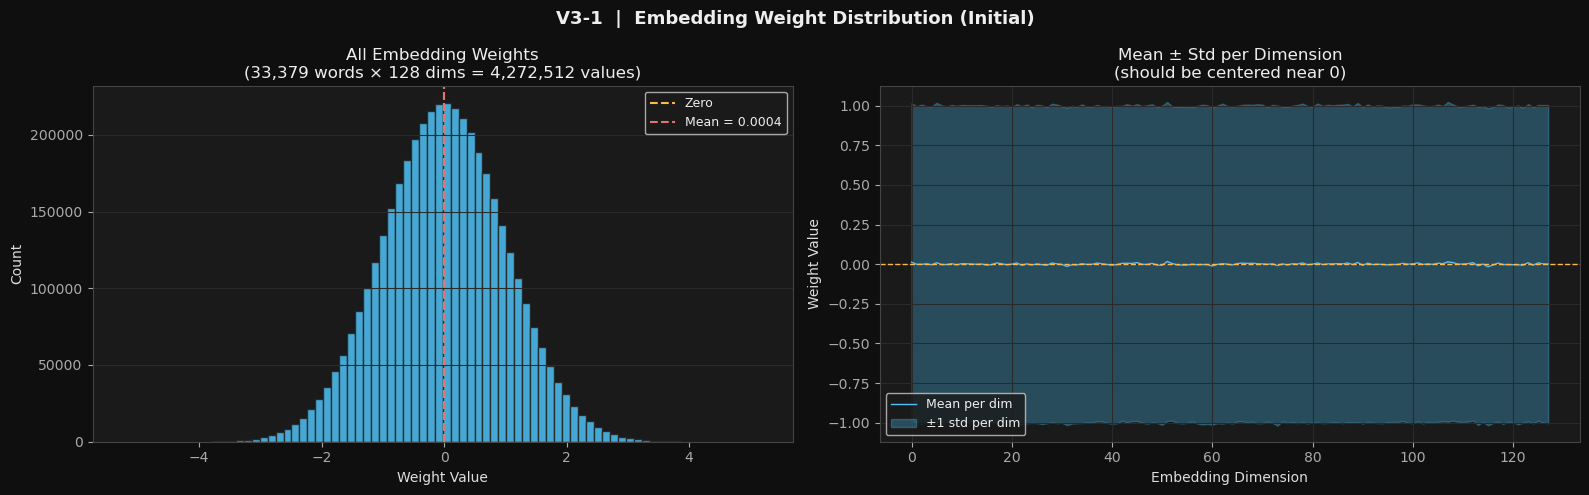

  Embedding weight stats:
  mean=0.00040  std=1.00000  min=-5.21839  max=5.17061
  ✓ Should be: mean ≈ 0, std ≈ 0.01–0.1, no all-zero rows (except PAD)
  PAD embedding is all-zero : ✓


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("V3-1  |  Embedding Weight Distribution (Initial)", fontsize=13, fontweight="bold")

weights = encoder.embedding.weight.data.cpu().numpy()

# Left: full distribution
ax = axes[0]
ax.hist(weights.flatten(), bins=80, color=ACCENT[0], edgecolor="#222", alpha=0.85)
ax.set_xlabel("Weight Value")
ax.set_ylabel("Count")
ax.set_title(f"All Embedding Weights\n({weights.shape[0]:,} words × {weights.shape[1]} dims = {weights.size:,} values)")
ax.axvline(0, color="#ffb74d", linestyle="--", linewidth=1.5, label="Zero")
ax.axvline(weights.mean(), color="#e57373", linestyle="--", linewidth=1.5,
           label=f"Mean = {weights.mean():.4f}")
ax.legend(fontsize=9)
ax.grid(True, axis="y")

# Right: per-dimension mean and std
ax = axes[1]
dim_means = weights.mean(axis=0)  # mean across all words for each dim
dim_stds  = weights.std(axis=0)
x = range(len(dim_means))
ax.plot(dim_means, color=ACCENT[0], linewidth=1, label="Mean per dim")
ax.fill_between(x,
                dim_means - dim_stds,
                dim_means + dim_stds,
                alpha=0.3, color=ACCENT[0], label="±1 std per dim")
ax.axhline(0, color="#ffb74d", linestyle="--", linewidth=1)
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Weight Value")
ax.set_title("Mean ± Std per Dimension\n(should be centered near 0)")
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig("v3_1_embedding_weights.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

print(f"  Embedding weight stats:")
print(f"  mean={weights.mean():.5f}  std={weights.std():.5f}  min={weights.min():.5f}  max={weights.max():.5f}")
print(f"  ✓ Should be: mean ≈ 0, std ≈ 0.01–0.1, no all-zero rows (except PAD)")

# Check PAD row is all zeros
pad_row = weights[vocab.PAD_IDX]
pad_zero = np.allclose(pad_row, 0)
print(f"  PAD embedding is all-zero : {'✓' if pad_zero else '✗ — PAD should be zero vector'}")

In [33]:
print("\n── V3-2: Output Tensor Sanity ──────────────────────────")

encoder.eval()
with torch.no_grad():
    src_b, tgt_b, sl, tl = next(iter(train_loader))
    src_b = src_b.to(DEVICE)
    sl    = sl.to(DEVICE)
    outputs, hidden = encoder(src_b, sl)

checks = [
    ("outputs shape",  outputs.shape == (BATCH_SIZE, MAX_SRC_LEN, HIDDEN_DIM),  str(outputs.shape)),
    ("hidden shape",   hidden.shape  == (NUM_LAYERS, BATCH_SIZE, HIDDEN_DIM),   str(hidden.shape)),
    ("outputs no NaN", not torch.isnan(outputs).any().item(),                   f"NaN count: {torch.isnan(outputs).sum().item()}"),
    ("hidden no NaN",  not torch.isnan(hidden).any().item(),                    f"NaN count: {torch.isnan(hidden).sum().item()}"),
    ("outputs no Inf", not torch.isinf(outputs).any().item(),                   f"Inf count: {torch.isinf(outputs).sum().item()}"),
    ("hidden no Inf",  not torch.isinf(hidden).any().item(),                    f"Inf count: {torch.isinf(hidden).sum().item()}"),
    ("outputs finite", outputs.abs().max().item() < 100,                        f"Max abs = {outputs.abs().max().item():.4f}"),
    ("hidden finite",  hidden.abs().max().item() < 100,                         f"Max abs = {hidden.abs().max().item():.4f}"),
]

all_pass = True
for name, passed, detail in checks:
    status = "✓" if passed else "✗"
    print(f"  {status} {name:30s} | {detail}")
    if not passed: all_pass = False

print(f"\n  {'✅ All tensor checks passed' if all_pass else '⚠️  Some checks failed — inspect encoder'}")
encoder.train()


── V3-2: Output Tensor Sanity ──────────────────────────
  ✓ outputs shape                  | torch.Size([64, 81, 256])
  ✓ hidden shape                   | torch.Size([2, 64, 256])
  ✓ outputs no NaN                 | NaN count: 0
  ✓ hidden no NaN                  | NaN count: 0
  ✓ outputs no Inf                 | Inf count: 0
  ✓ hidden no Inf                  | Inf count: 0
  ✓ outputs finite                 | Max abs = 0.9044
  ✓ hidden finite                  | Max abs = 0.4525

  ✅ All tensor checks passed


Encoder(
  (embedding): Embedding(33379, 128, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (rnn): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=256, bias=True)
  (out_dropout): Dropout(p=0.5, inplace=False)
)

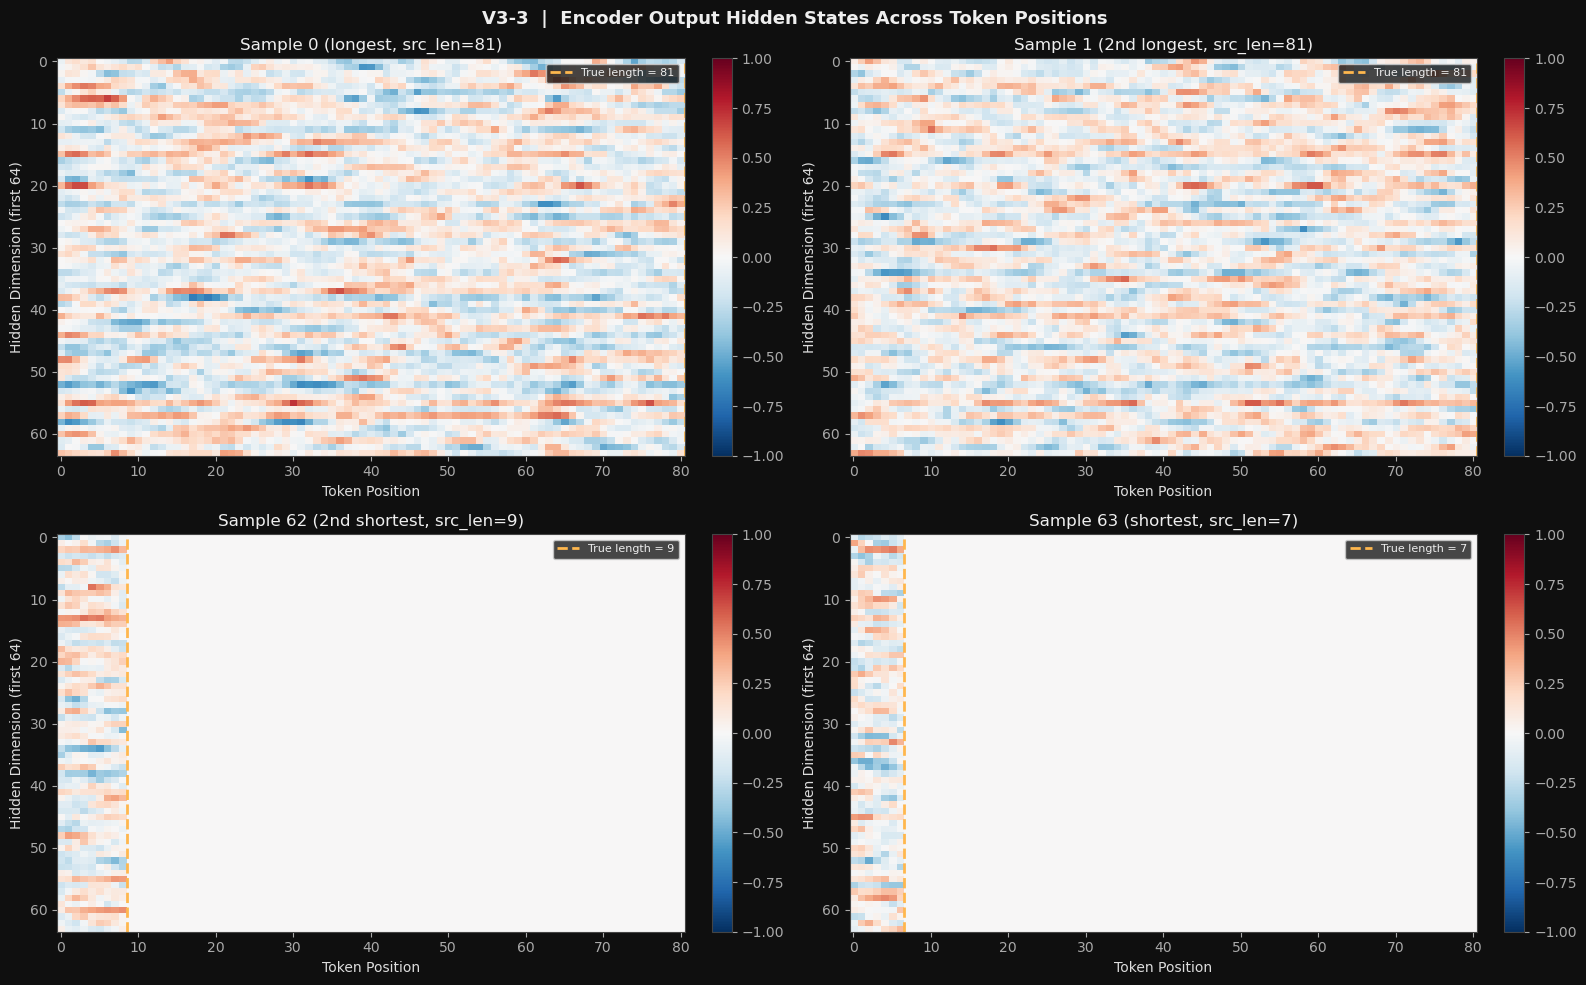

What to look for:
  - Columns LEFT of the yellow line  → active, colorful (real tokens)
  - Columns RIGHT of the yellow line → dark/zero (PAD positions)
  - Visible structure/variation across rows → encoder is learning representations


Encoder(
  (embedding): Embedding(33379, 128, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (rnn): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=256, bias=True)
  (out_dropout): Dropout(p=0.5, inplace=False)
)

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("V3-3  |  Encoder Output Hidden States Across Token Positions", fontsize=13, fontweight="bold")

encoder.eval()
with torch.no_grad():
    src_b, _, sl, _ = next(iter(train_loader))
    src_b = src_b.to(DEVICE)
    sl    = sl.to(DEVICE)
    outputs, _ = encoder(src_b, sl)

sample_indices = [0, 1, -2, -1]   # longest 2 and shortest 2 in the sorted batch
labels = [f"Sample 0 (longest, src_len={sl[0].item()})",
          f"Sample 1 (2nd longest, src_len={sl[1].item()})",
          f"Sample {BATCH_SIZE-2} (2nd shortest, src_len={sl[-2].item()})",
          f"Sample {BATCH_SIZE-1} (shortest, src_len={sl[-1].item()})"]

for ax, idx, label in zip(axes.flat, sample_indices, labels):
    # Shape: (src_len, hidden_dim) → show first 64 hidden dims for readability
    hidden_states = outputs[idx, :, :64].cpu().numpy()
    true_len      = sl[idx].item()

    im = ax.imshow(hidden_states.T, aspect="auto", cmap="RdBu_r",
                   vmin=-1, vmax=1, interpolation="nearest")
    ax.axvline(true_len - 0.5, color="#ffb74d", linewidth=2, linestyle="--",
               label=f"True length = {true_len}")
    ax.set_xlabel("Token Position")
    ax.set_ylabel("Hidden Dimension (first 64)")
    ax.set_title(label)
    ax.legend(fontsize=8, loc="upper right")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("v3_3_hidden_states.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("What to look for:")
print("  - Columns LEFT of the yellow line  → active, colorful (real tokens)")
print("  - Columns RIGHT of the yellow line → dark/zero (PAD positions)")
print("  - Visible structure/variation across rows → encoder is learning representations")
encoder.train()

In [45]:
print("\n── V3-4: PAD Position Zero Check ───────────────────────")

encoder.eval()
with torch.no_grad():
    src_b, _, sl, _ = next(iter(train_loader))
    outputs, _ = encoder(src_b.to(DEVICE), sl.to(DEVICE))
    outputs = outputs.cpu()

errors = 0
total_checked = 0
max_pad_value = 0.0

for i in range(BATCH_SIZE):
    true_len = sl[i].item()
    pad_region = outputs[i, true_len:, :]   # everything after true length
    total_checked += pad_region.numel()
    if pad_region.numel() == 0:
        pass
    else:
        pad_max = pad_region.abs().max().item()
        max_pad_value = max(max_pad_value, pad_max)
        if pad_max > 1e-6:
            errors += 1

print(f"  Samples checked        : {BATCH_SIZE}")
print(f"  Total PAD values       : {total_checked:,}")
print(f"  Samples with non-zero PAD : {errors}")
print(f"  Max absolute PAD value    : {max_pad_value:.2e}")
print(f"  {'✅ All PAD positions are zero — attention will not attend to padding' if errors == 0 else '⚠️  PAD positions non-zero — check pack/unpack logic'}")
encoder.train()


── V3-4: PAD Position Zero Check ───────────────────────
  Samples checked        : 64
  Total PAD values       : 687,616
  Samples with non-zero PAD : 0
  Max absolute PAD value    : 0.00e+00
  ✅ All PAD positions are zero — attention will not attend to padding


Encoder(
  (embedding): Embedding(33379, 128, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (rnn): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=256, bias=True)
  (out_dropout): Dropout(p=0.5, inplace=False)
)

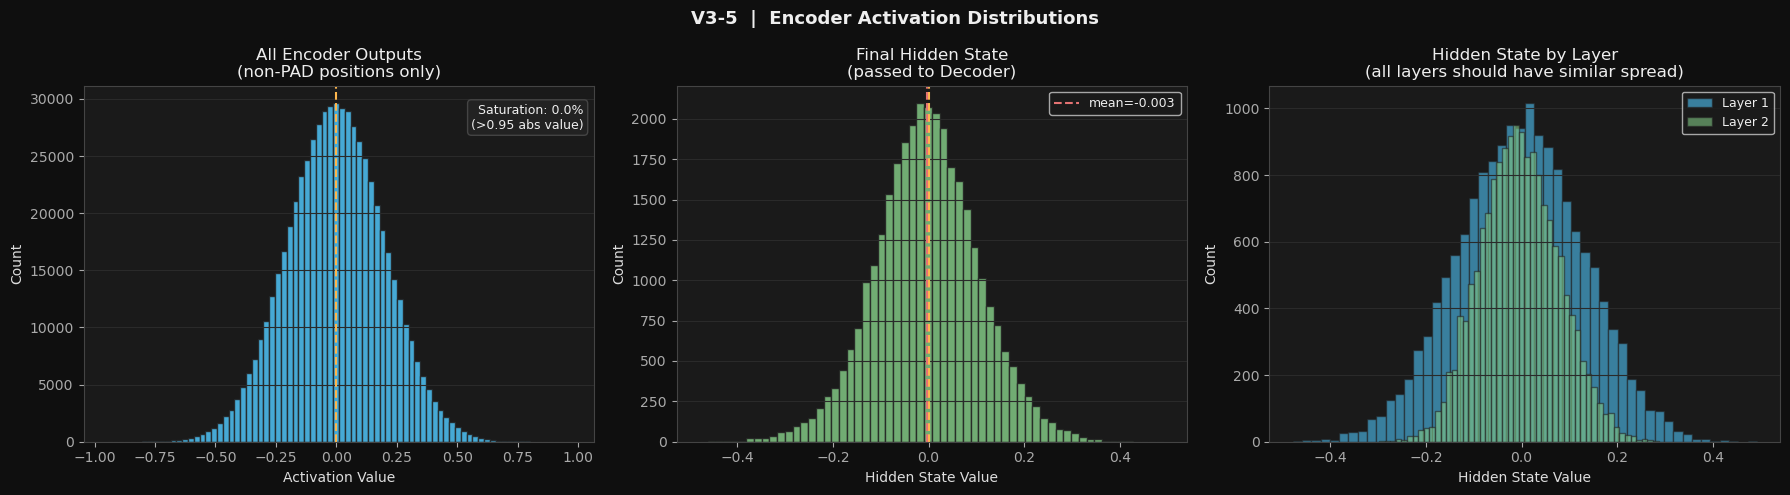

  Output activation stats (non-PAD):
    mean=-0.0028  std=0.2001
    min=-0.9492   max=0.9703
    Saturation % (|val|>0.95): 0.0%
  ✅ Healthy activations


Encoder(
  (embedding): Embedding(33379, 128, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (rnn): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=256, bias=True)
  (out_dropout): Dropout(p=0.5, inplace=False)
)

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("V3-5  |  Encoder Activation Distributions", fontsize=13, fontweight="bold")

encoder.eval()
with torch.no_grad():
    src_b, _, sl, _ = next(iter(train_loader))
    outputs, hidden = encoder(src_b.to(DEVICE), sl.to(DEVICE))

# Left: all encoder outputs (only non-PAD positions)
ax = axes[0]
# Mask out PAD positions before computing stats
mask = torch.zeros(BATCH_SIZE, MAX_SRC_LEN, dtype=torch.bool)
for i in range(BATCH_SIZE):
    mask[i, :sl[i].item()] = True
mask = mask.unsqueeze(-1).expand_as(outputs.cpu())
valid_outputs = outputs.cpu()[mask].numpy()

ax.hist(valid_outputs, bins=80, color=ACCENT[0], edgecolor="#222", alpha=0.85)
ax.set_xlabel("Activation Value")
ax.set_ylabel("Count")
ax.set_title(f"All Encoder Outputs\n(non-PAD positions only)")
ax.axvline(0, color="#ffb74d", linestyle="--", linewidth=1.5)
sat_pct = (np.abs(valid_outputs) > 0.95).mean() * 100
ax.text(0.98, 0.95, f"Saturation: {sat_pct:.1f}%\n(>0.95 abs value)",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="#222", edgecolor="#444"))
ax.grid(True, axis="y")

# Middle: final hidden state (what gets passed to decoder)
ax = axes[1]
hidden_vals = hidden.cpu().numpy().flatten()
ax.hist(hidden_vals, bins=60, color=ACCENT[1], edgecolor="#222", alpha=0.85)
ax.set_xlabel("Hidden State Value")
ax.set_ylabel("Count")
ax.set_title(f"Final Hidden State\n(passed to Decoder)")
ax.axvline(0, color="#ffb74d", linestyle="--", linewidth=1.5)
ax.axvline(hidden_vals.mean(), color="#e57373", linestyle="--", linewidth=1.5,
           label=f"mean={hidden_vals.mean():.3f}")
ax.legend(fontsize=9)
ax.grid(True, axis="y")

# Right: hidden state magnitude per layer
ax = axes[2]
for layer_idx in range(NUM_LAYERS):
    layer_hidden = hidden[layer_idx].cpu().numpy().flatten()
    ax.hist(layer_hidden, bins=50, alpha=0.6, label=f"Layer {layer_idx+1}",
            color=ACCENT[layer_idx], edgecolor="#222")
ax.set_xlabel("Hidden State Value")
ax.set_ylabel("Count")
ax.set_title("Hidden State by Layer\n(all layers should have similar spread)")
ax.legend(fontsize=9)
ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("v3_5_activations.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

print(f"  Output activation stats (non-PAD):")
print(f"    mean={valid_outputs.mean():.4f}  std={valid_outputs.std():.4f}")
print(f"    min={valid_outputs.min():.4f}   max={valid_outputs.max():.4f}")
print(f"    Saturation % (|val|>0.95): {sat_pct:.1f}%")
print(f"  {'✅ Healthy activations' if sat_pct < 20 else '⚠️  High saturation — may need smaller init or lower LR'}")
encoder.train()

In [49]:
print("\n── V3-6: Gradient Flow Check ────────────────────────────")

encoder.train()
encoder.zero_grad()

# Create a fake loss from encoder outputs
src_b, _, sl, _ = next(iter(train_loader))
outputs, hidden = encoder(src_b.to(DEVICE), sl.to(DEVICE))
fake_loss = outputs.mean() + hidden.mean()
fake_loss.backward()

print(f"  {'Layer Name':35s}  {'Grad Mean':>12}  {'Grad Std':>12}  {'Status'}")
print(f"  {'─'*75}")

grad_issues = []
for name, param in encoder.named_parameters():
    if param.grad is not None:
        g_mean = param.grad.abs().mean().item()
        g_std  = param.grad.std().item()
        status = "✓"
        if g_mean < 1e-8:
            status = "✗ DEAD"
            grad_issues.append(name)
        elif g_mean > 10:
            status = "⚠ EXPLODING"
            grad_issues.append(name)
        print(f"  {name:35s}  {g_mean:>12.6f}  {g_std:>12.6f}  {status}")
    else:
        print(f"  {name:35s}  {'NO GRADIENT':>12}  {'':>12}  ✗")
        grad_issues.append(name)

print()
if not grad_issues:
    print("  ✅ Gradients flow through all layers — encoder will train correctly")
else:
    print(f"  ⚠️  Issues found in: {grad_issues}")

encoder.zero_grad()


── V3-6: Gradient Flow Check ────────────────────────────
  Layer Name                              Grad Mean      Grad Std  Status
  ───────────────────────────────────────────────────────────────────────────
  embedding.weight                         0.000000      0.000001  ✓
  rnn.weight_ih_l0                         0.000097      0.000226  ✓
  rnn.weight_hh_l0                         0.000009      0.000019  ✓
  rnn.bias_ih_l0                           0.000374      0.000795  ✓
  rnn.bias_hh_l0                           0.000196      0.000401  ✓
  rnn.weight_ih_l0_reverse                 0.000064      0.000120  ✓
  rnn.weight_hh_l0_reverse                 0.000010      0.000020  ✓
  rnn.bias_ih_l0_reverse                   0.000375      0.000783  ✓
  rnn.bias_hh_l0_reverse                   0.000194      0.000395  ✓
  rnn.weight_ih_l1                         0.000030      0.000066  ✓
  rnn.weight_hh_l1                         0.000013      0.000028  ✓
  rnn.bias_ih_l1              

In [51]:
print("\n── V3-7: Determinism Check (same input = same output) ──")

encoder.eval()
with torch.no_grad():
    src_b, _, sl, _ = next(iter(train_loader))
    src_b = src_b.to(DEVICE)
    sl    = sl.to(DEVICE)

    _, hidden1 = encoder(src_b, sl)
    _, hidden2 = encoder(src_b, sl)

max_diff = (hidden1 - hidden2).abs().max().item()
is_deterministic = max_diff < 1e-6
print(f"  Max difference between two runs on same input: {max_diff:.2e}")
print(f"  {'✅ Encoder is deterministic in eval mode' if is_deterministic else '⚠️  Non-deterministic — check for randomness in forward pass'}")
encoder.train()


print("\n" + "="*60)
print("✅  ALL STEP 3 VERIFICATIONS COMPLETE")
print("="*60)
print(f"\nValues to carry into Step 4 (Attention) & Step 5 (Decoder):")
print(f"  encoder          → the trained Encoder object")
print(f"  EMBEDDING_DIM    = {EMBEDDING_DIM}")
print(f"  HIDDEN_DIM       = {HIDDEN_DIM}")
print(f"  NUM_LAYERS       = {NUM_LAYERS}")
print(f"  DROPOUT          = {DROPOUT}")
print(f"  outputs shape    = (batch, {MAX_SRC_LEN}, {HIDDEN_DIM})  ← Attention uses this")
print(f"  hidden shape     = ({NUM_LAYERS}, batch, {HIDDEN_DIM})   ← Decoder starts from this")
print(f"\n→ Next: Step 4 — Attention Mechanism")


── V3-7: Determinism Check (same input = same output) ──
  Max difference between two runs on same input: 0.00e+00
  ✅ Encoder is deterministic in eval mode

✅  ALL STEP 3 VERIFICATIONS COMPLETE

Values to carry into Step 4 (Attention) & Step 5 (Decoder):
  encoder          → the trained Encoder object
  EMBEDDING_DIM    = 128
  HIDDEN_DIM       = 256
  NUM_LAYERS       = 2
  DROPOUT          = 0.5
  outputs shape    = (batch, 81, 256)  ← Attention uses this
  hidden shape     = (2, batch, 256)   ← Decoder starts from this

→ Next: Step 4 — Attention Mechanism
